<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Introducci%C3%B3n-al-Aprendizaje-Autom%C3%A1tico/Practico%201/IAA_2026_Entregable_P1_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 1: Regresión en California

En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

## Sobre este Trabajo Práctico

El objetivo de este trabajo es que puedas aplicar los conceptos de regresión sobre un dataset real, tomando decisiones propias en cada etapa: qué atributos usar, qué modelo elegir y cómo interpretar los resultados.

No se trata solo de ejecutar el código: se espera que puedas **justificar tus elecciones**, **interpretar los errores obtenidos** y **explicar qué está pasando** en cada experimento.

Al finalizar, deberías poder responder: ¿qué modelo elegirías para este problema y por qué? ¿Cómo reconocés underfitting y overfitting en tus resultados?



In [161]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import inspect

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [162]:
california = fetch_california_housing()

Con la aplicacion de la siguiente funcion, vemos que `california` es un diccionario.

In [163]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [164]:
inspect.signature(fetch_california_housing)

<Signature (*, data_home=None, download_if_missing=True, return_X_y=False, as_frame=False, n_retries=3, delay=1.0)>

Estudiemos sus caracteristicas principales

In [165]:
print(california['DESCR'])  # descripción del dataset

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [166]:
california['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [167]:
california['target_names']

['MedHouseVal']

Los datos del diccionario relevantes a nuestro analisis se almacenan en `california.data` y `california.target`. Veamos el tamaño de estos conjuntos de datos:

In [168]:
print(california['data'].shape, california['target'].shape)

(20640, 8) (20640,)


Guardamos los datos en objetos separados

If `return_X_y=True`, returns (data.data, data.target) instead of a Bunch object.

If `as_frame=True`, the data is a pandas DataFrame including columns with appropriate dtypes (numeric, string or categorical). The target is a pandas DataFrame or Series depending on the number of target_columns.

In [169]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)

In [170]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


fetch_california_housing no es un dataset "crudo" obtenido directamente del censo. Es una versión procesada y curada del dataset California Housing derivado del censo de 1990 y distribuido para fines educativos a través de scikit-learn. Por diseño:

- No contiene valores faltantes,
- Tiene tipos de datos consistentes,
- Las variables son numéricas,
- Ya pasó por un proceso previo de preparación.

Con esto presente, se opta por hacer una auditoría en lugar de una limpieza formal.

In [171]:
# Verificacion de ausencia de nulos
X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


In [172]:
# Verificacion de ausencia de duplicados
X.duplicated().sum()

np.int64(0)

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [173]:
# Random seed used: 0
# Data percent for training: 80%
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

In [174]:
X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [175]:
y_train.shape, y_test.shape

((16512,), (4128,))

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

In [176]:
# Estadistica descriptiva de valores de data
X.describe(percentiles=[.95,.99,.995])

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
95%,7.300305,52.000000,7.640247,1.273006,3288.000000,4.333417,38.960000,-117.080000
99%,10.596540,52.000000,10.357033,2.127541,5805.830000,5.394812,40.626100,-116.290000
99.5%,12.253355,52.000000,15.754932,3.112918,7233.635000,6.122155,40.880000,-115.570000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


Se observan grandes diferencias entre el percentil 99.5 y el valor máximo en AveRooms, AveBedrms y AveOccup. Esto limita la capacidad de las visualizaciones de detectar patrones en los datos sin otro tratamiento.

Se graficará la relación entre cada atributo y el target utilizando todos los datos y, luego, eliminando los valores más altos.

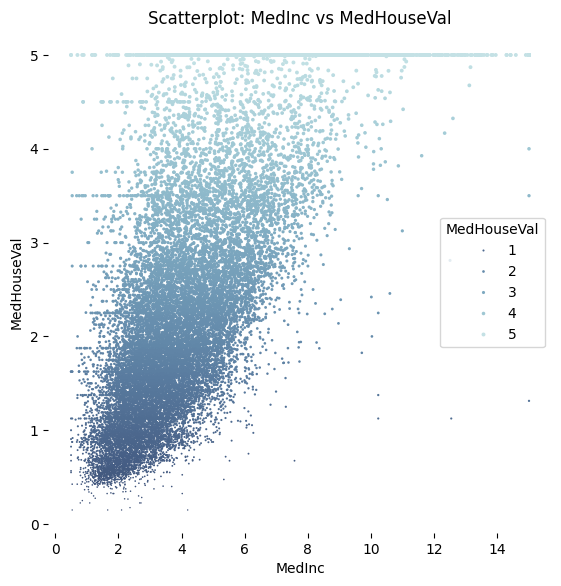

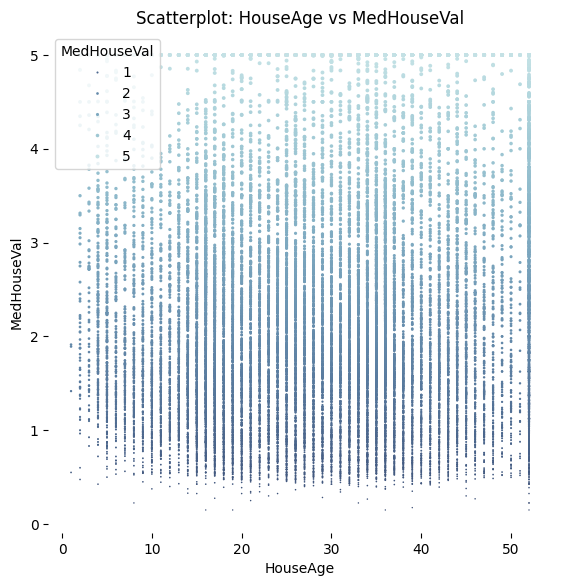

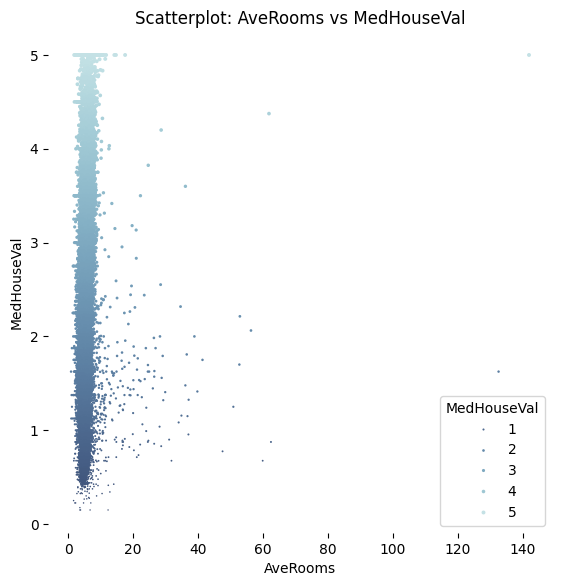

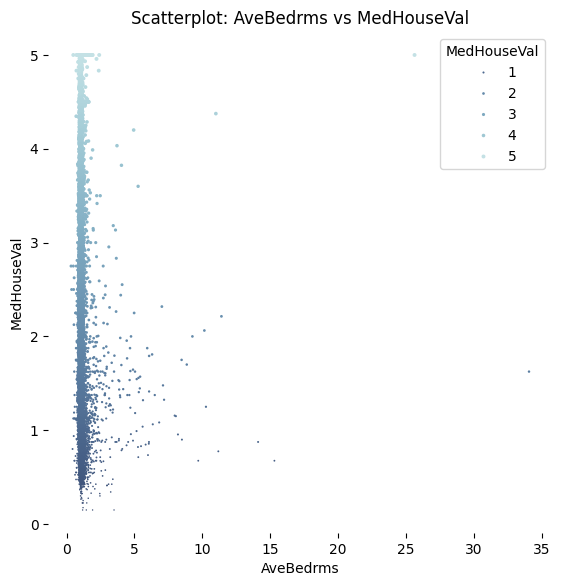

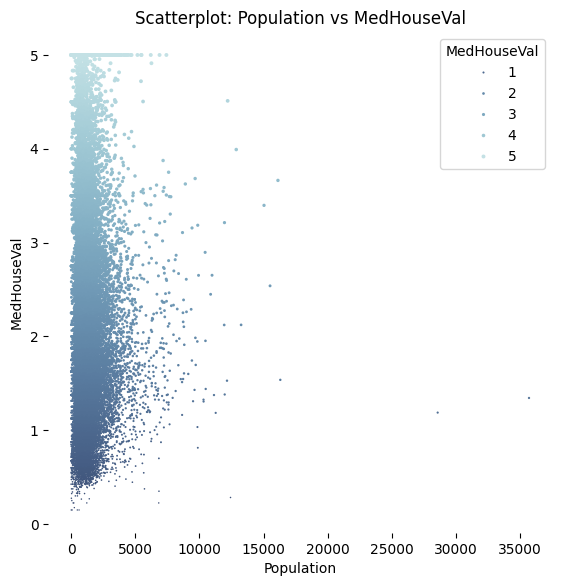

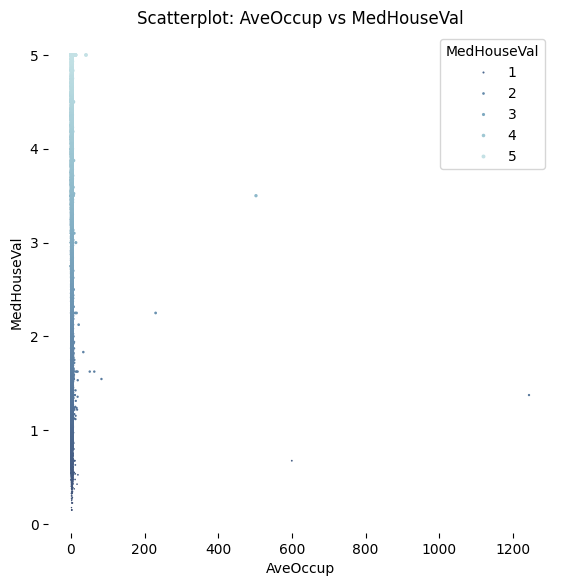

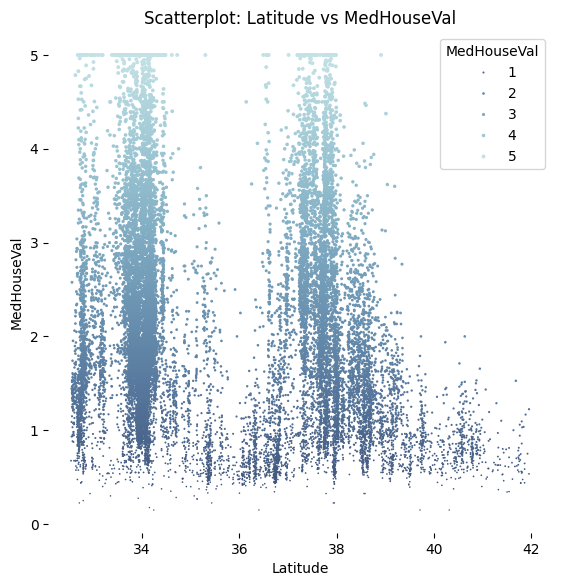

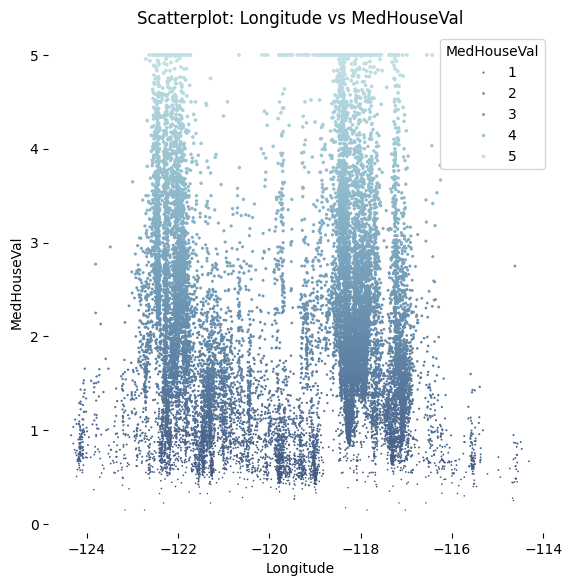

In [177]:
for feature_name in california['feature_names']:
    f, ax = plt.subplots(figsize=(6.5, 6.5))
    sns.despine(f, left=True, bottom=True)
    sns.scatterplot(x=X[feature_name], y=y,
                    hue=y, size=y,
                    palette="ch:r=-.2,d=.3_r",
                    sizes=(1, 8), linewidth=0,
                    ax=ax)
    ax.set_xlabel(feature_name)
    ax.set_ylabel(california['target_names'][0])
    ax.set_title(f"Scatterplot: {feature_name} vs {california['target_names'][0]}")
    plt.show()

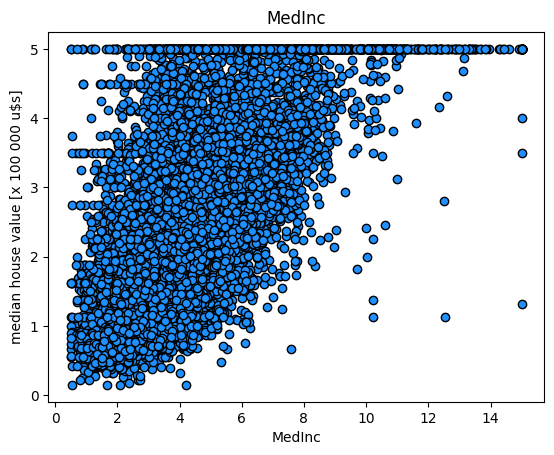

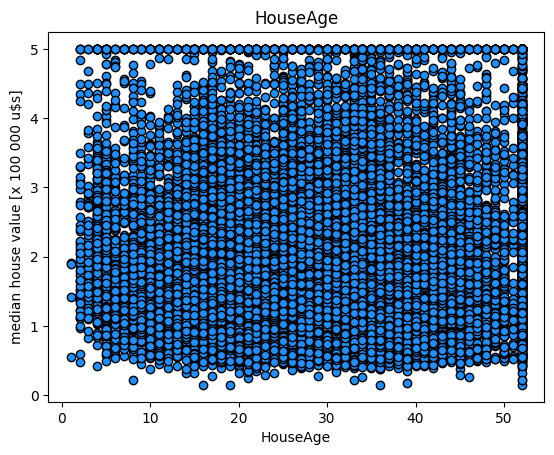

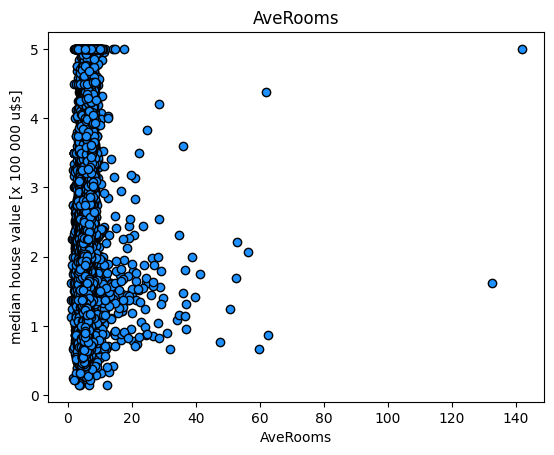

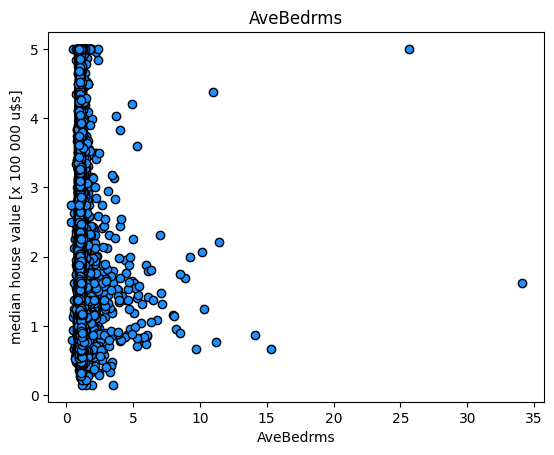

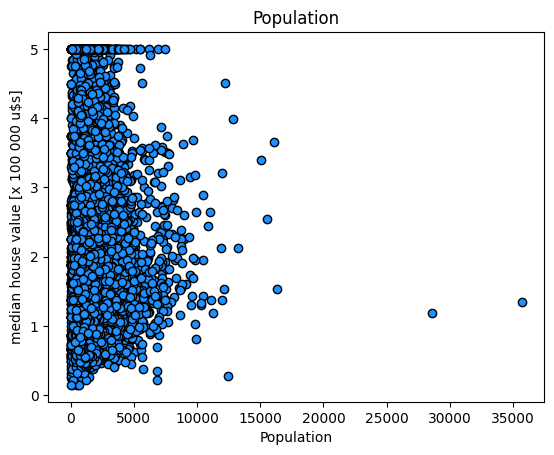

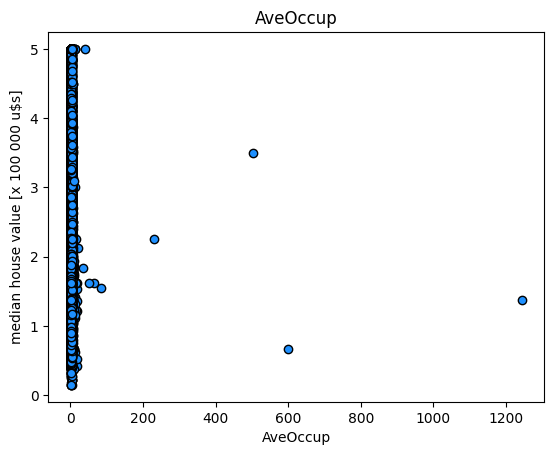

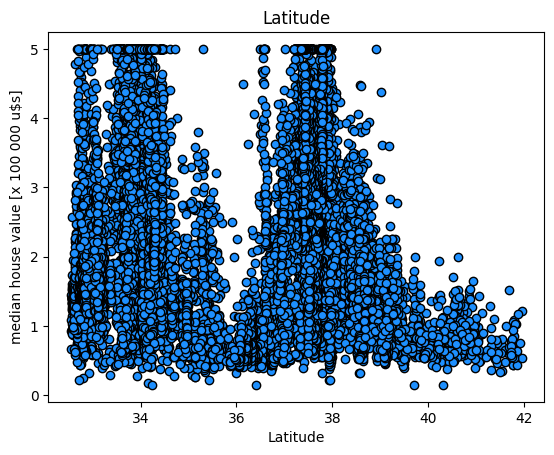

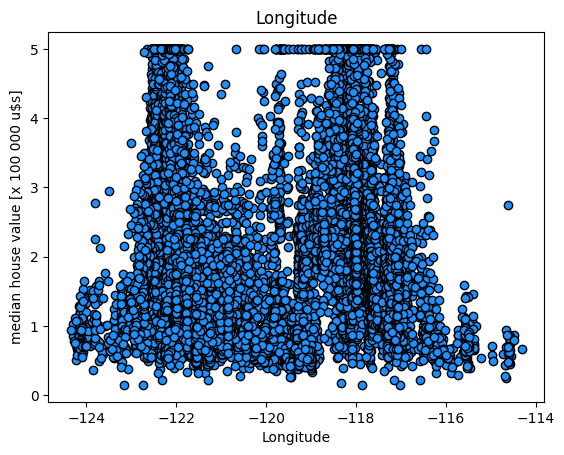

In [178]:
for feature_name in california['feature_names']:
    selector = (np.array(california['feature_names']) == feature_name)
    plt.scatter(X[feature_name], y, facecolor="dodgerblue", edgecolor="k", label="datos")
    plt.xlabel(feature_name)
    plt.ylabel('median house value [x 100 000 u$s]')
    plt.title(feature_name)
    plt.show()

En los datasets sin ningún tipo de limpieza pueden observarse relaciones significativas entre MedInc y medHouseVal.

La relación con AveRooms, AveBedrms, Population y AveOccup no es del todo clara debido a la presencia de valores atípicamente altos, pero si se reconoce una aparente relacion directa de crecimiento.

La relación con HouseAge no permite extraer información debido a la dispersión de datos.

La relación con las variables geográficas es evidentemente no lineal, más compleja que el caso de las demás variables.

Se realiza una visualizacion en escala logarítmica

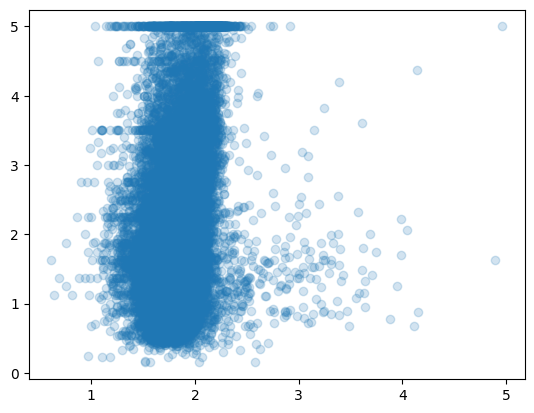

In [179]:
X_vis = X.copy()

X_vis["Population_log"] = np.log1p(X_vis["Population"])
X_vis["AveRooms_log"] = np.log1p(X_vis["AveRooms"])
X_vis["AveOccup_log"] = np.log1p(X_vis["AveOccup"])
plt.scatter(
    X_vis["AveRooms_log"],
    y,
    alpha=0.2
)

Haciendo esta limpieza exploratoria, en una copia del dataset original, podemos ver que la relación entre las variables con outliers y el target no es tan clara luego de filtrar con percentil 99. Con esto presente, los atributos más informativos ordenados por relevancia resultan ser:

1. MedInc
2. Longitud
3. Latitud
4. AveRooms



---


### De acá en adelante sin cambios!!


---



## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

### Solución - Ejercicio 3

1. Atributo seleccionado: `MedInc`. De los preseleccionados como significativos, con sólo observar la dispersión de atos se concluye que es el único feature que vale la pena asociar a un comportamiento lineal.

In [180]:
feature = 'MedInc' # selecciono el atributo 'MedInc'
selector = (np.array(california['feature_names']) == feature)
X_train_f = X_train.loc[:, selector]
X_test_f = X_test.loc[:, selector]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [181]:
X_train_f.loc[1]

,1
MedInc,8.3014


In [182]:
from sklearn.linear_model import LinearRegression

# Create a linear regression model and fit it on the training data.
# by default, an intercept is added to the model.
regressor = LinearRegression()
regressor.fit(X_train_f, y_train)

LinearRegression()

In [183]:
from sklearn.metrics import mean_squared_error, r2_score

# We evaluate the model’s performance on the test set using the mean squared
# error and the coefficient of determination.
y_pred = regressor.predict(X_test_f)

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 0.72
Coefficient of determination: 0.45


In [184]:
print(regressor.coef_)
print(regressor.intercept_)

[0.42032178]
0.4432063522765708


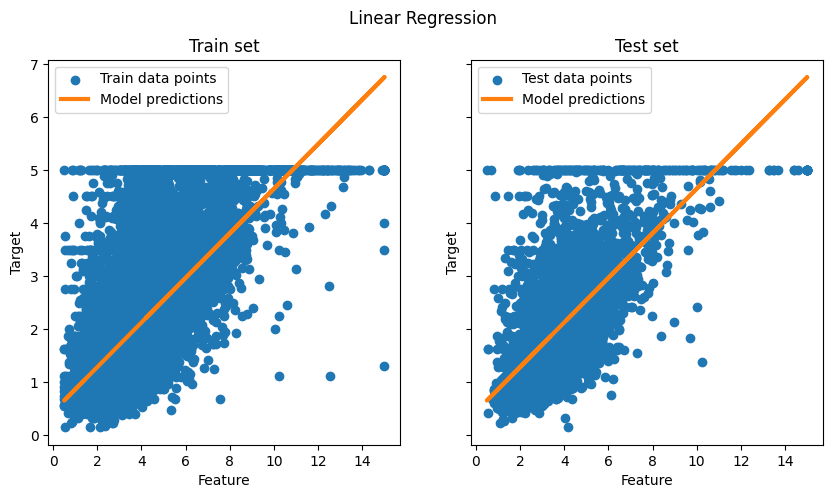

In [185]:
# visualize the results on the train and test data.
fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train_f, y_train, label="Train data points")
ax[0].plot(
    X_train_f,
    regressor.predict(X_train_f),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test_f, y_test, label="Test data points")
ax[1].plot(X_test_f, y_pred, linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [186]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [187]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pf = PolynomialFeatures(degrees)
lr = LinearRegression(fit_intercept=False)  # el bias ya esta como feature
model = make_pipeline(pf, lr)

In [188]:
mse_train_list = []
mse_test_list = []

for degree in degrees:
    model.set_params(polynomialfeatures__degree=degree)
    model.fit(X_train_f, y_train)

    y_pred_train = model.predict(X_train_f)
    y_pred_test = model.predict(X_test_f)

    mse_train_list.append(mean_squared_error(y_train, y_pred_train))
    mse_test_list.append(mean_squared_error(y_test, y_pred_test))

    print(f"Grado {degree:2d} — MSE train: {mse_train_list[-1]:.4f} | MSE test: {mse_test_list[-1]:.4f}")

Grado  1 — MSE train: 0.6961 | MSE test: 0.7215
Grado  2 — MSE train: 0.6895 | MSE test: 0.7174
Grado  3 — MSE train: 0.6782 | MSE test: 0.7081
Grado  4 — MSE train: 0.6781 | MSE test: 0.7080
Grado  5 — MSE train: 0.6780 | MSE test: 0.7080
Grado  6 — MSE train: 0.6761 | MSE test: 0.7068
Grado  7 — MSE train: 0.6737 | MSE test: 0.7026
Grado  8 — MSE train: 0.6736 | MSE test: 0.7021
Grado  9 — MSE train: 0.6741 | MSE test: 0.7028
Grado 10 — MSE train: 0.6825 | MSE test: 0.7127


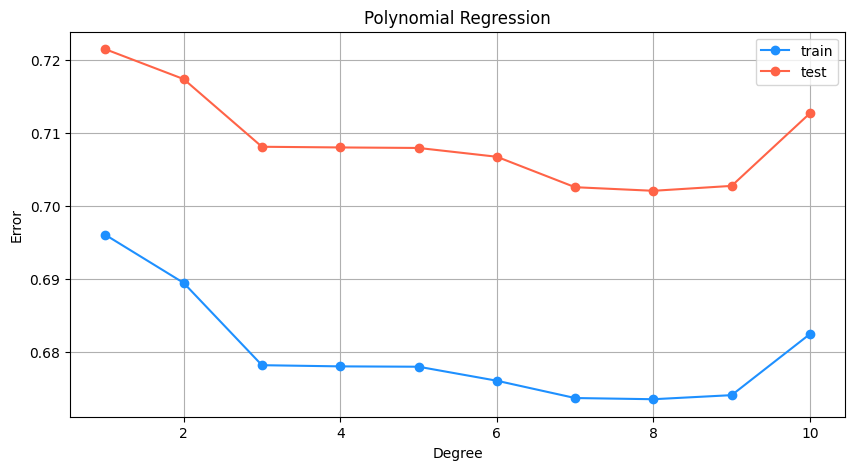

In [189]:
# Graficar curva de errores en funcion del polinomio
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, mse_train_list, marker='o', label='train', color='dodgerblue')
ax.plot(degrees, mse_test_list, marker='o', label='test', color='tomato')
ax.set(xlabel="Degree", ylabel="Error", title="Polynomial Regression")
ax.grid()
ax.legend()
plt.show()

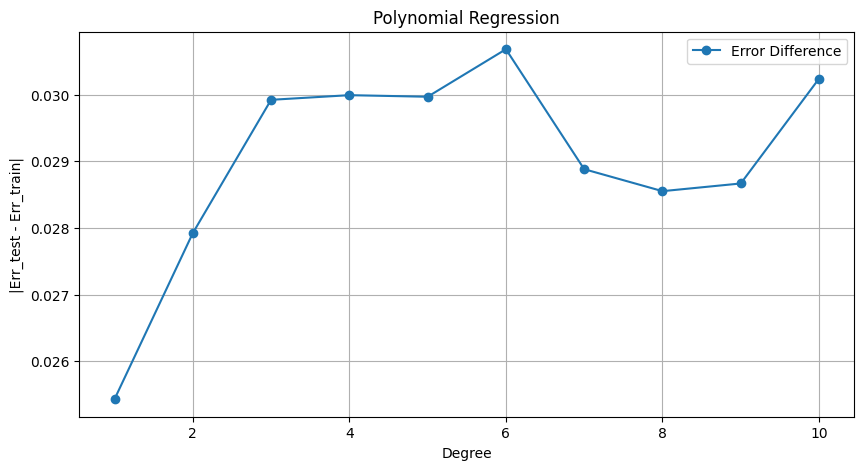

In [190]:
# Guardar la diferencia absoluta entre errores en un array y graficar en funcion del orden del polinomio
diff_errors = np.abs(np.array(mse_train_list) - np.array(mse_test_list))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, diff_errors, marker='o', label="Error Difference")
ax.set(xlabel="Degree", ylabel="|Err_test - Err_train|", title="Polynomial Regression")
ax.grid()
ax.legend()
plt.show()

En función de todo lo visto anteriormente, se observa que el modelo que mejor ajusta el dataset es el polinomio de grado 8

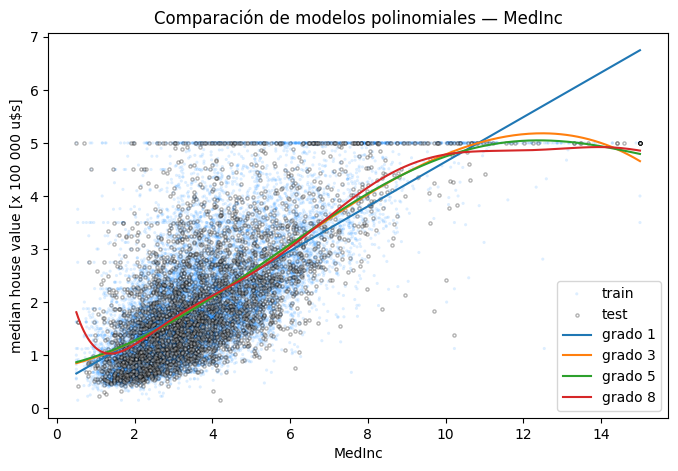

In [199]:
degrees_plot = [1, 3, 5, 8]
x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.15, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.3, s=5, label="test")

for d in degrees_plot:
    model.set_params(polynomialfeatures__degree=d)
    model.fit(X_train_f.values, y_train)

    ax.plot(x_range, model.predict(x_range), linewidth=1.5, label=f"grado {d}")

ax.set_xlabel("MedInc")
ax.set_ylabel("median house value [x 100 000 u$s]")
ax.set_title("Comparación de modelos polinomiales — MedInc")
ax.legend()
plt.show()

Mejor grado: 8


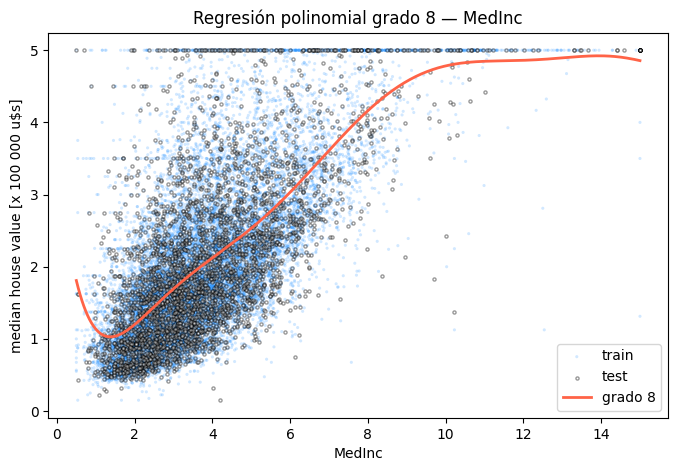

In [201]:
# 4. Reconstruir mejor modelo acá y graficar.
best_degree = degrees[mse_test_list.index(min(mse_test_list))]
print(f"Mejor grado: {best_degree}")

model.set_params(polynomialfeatures__degree=best_degree)
model.fit(X_train_f.values, y_train)

x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.2, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.4, s=5, label="test")
ax.plot(x_range, model.predict(x_range), color="tomato", linewidth=2, label=f"grado {best_degree}")
ax.set_xlabel('MedInc')
ax.set_ylabel('median house value [x 100 000 u$s]')
ax.set_title(f'Regresión polinomial grado {best_degree} — MedInc')
ax.legend()
plt.show()

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [ ]:
# 1. Resolver acá. Ayuda (con dos atributos):
selector = (np.array(california['feature_names']) == 'HouseAge') | (np.array(california['feature_names']) == 'AveRooms')

X_train_fs = X_train[:, selector]
X_test_fs = X_test[:, selector]
X_train_fs.shape, X_test_fs.shape

In [ ]:
# 2. Resolver acá.

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


---
## Reflexión sobre el proceso de trabajo

Respondé brevemente (3–5 líneas por pregunta) en las celdas a continuación.

**a) ¿Usaste alguna herramienta de IA (ChatGPT, Claude, Copilot, etc.) durante este trabajo? ¿Para qué?**

*Escribí tu respuesta acá.*

**b) Si usaste IA: ¿qué tuviste que entender vos para validar lo que te produjo? ¿Hubo algo que te pareció incorrecto o que tuviste que corregir?**

*Escribí tu respuesta acá.*

**c) Si no usaste IA: ¿qué recursos o estrategias usaste cuando te trabaste?**

*Escribí tu respuesta acá.*